# 02 Test Enviroment Hill Terrain

This notebook is to serve as a test ground for building an numerical shortest path optimiser we wiill now add a hill into the mixture and then build a optimiser to solve this

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

print("Environment working!")

Environment working!


Initially, I want to test my optimisation methods on a uniform cost field with uniform costs and no terrain features. The terrain is a over a domain of 
$$
\Omega = [0,\text{width}] \times [0,\text{height}]
$$

The cost is a function 
$$
c : \Omega \rightarrow [0,1]
$$

The $c = 0.1$ uniformly except for a hill in the centre

We add a smooth circular hill centred in the middle of the domain with radius $r=30$. 
The hill has a peak cost of $0.8$ at its centre and smoothly transitions back to the 
uniform background cost of $0.1$.

The resulting terrain cost field is modelled using a Gaussian function:

$
c(x,y)=0.1+0.7\exp\left(-\frac{d^2}{2\sigma^2}\right)
$

where $d$ is the Euclidean distance from the centre of the hill and $\sigma$ controls 
the spread of the Gaussian profile. In this case, we choose:

$
\sigma=\frac{r}{3}
$

so that the influence of the hill smoothly decreases within the specified radius.

Outside the radius $r$, the terrain returns to the uniform background cost:
$
c(x,y)=0.1
$

In [2]:
import sys

sys.path.append("../src")

from terrain.terrain import Terrain

In [3]:
terrain = Terrain(
    width=100,
    height=100,
    resolution=100,
    cost=0.1
)

terrain.add_hill(
    centre=(50, 50),
    peak_cost=0.8,
    radius=30

)

terrain.grid.shape
terrain_df = terrain.to_dataframe()

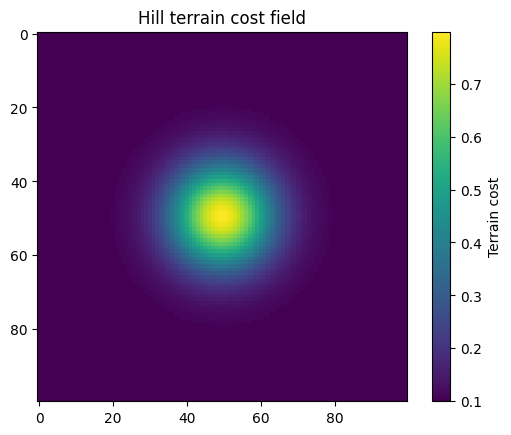

In [4]:
plt.imshow(terrain_df)

plt.colorbar(label="Terrain cost")

plt.title("Hill terrain cost field")

plt.show()

Next I want to add end points for my curve. These points are analogous to train stations or towns.

In [5]:
from geometry.endpoints import Endpoints

boundary = Endpoints(
    start=(10, 20),
    end=(80, 80)
)

boundary_df = boundary.to_dataframe()

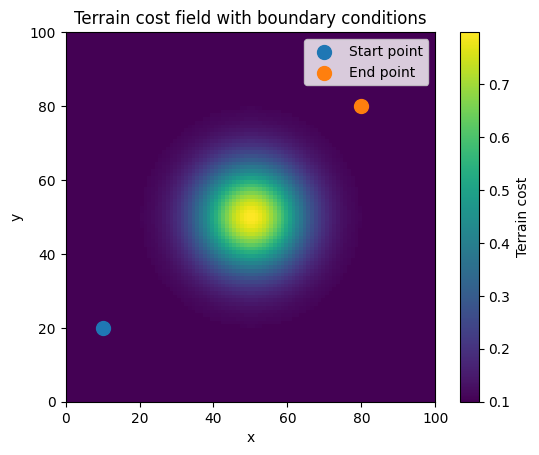

In [6]:

start = boundary_df[boundary_df["point"] == "start"]

end = boundary_df[boundary_df["point"] == "end"]

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.colorbar(label="Terrain cost")

plt.scatter(
    start["x"],
    start["y"],
    label="Start point",
    s=100

)

plt.scatter(
    end["x"],
    end["y"],
    label="End point",
    s=100

)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

I want to optimise the cost of this path. we should get shortest path more distance increases cost. the functional becomes
$$
J(\gamma) = \int_\gamma c(x,y) \, ds
$$
next we discretise the points along the path. so get 
$$
J(\gamma_h) = \sum_{i=0}^{N-1} c(p_i)|p_{i+1} - p_i|
$$

I have a straight_line_path function to create a straight line though the two points. no optimisation just yet. just an initial solution

In [7]:
from geometry.path import Path

In [8]:
from geometry.generators import straight_line_path


path = straight_line_path(
    start=boundary.start,
    end=boundary.end,
    num_points=100
)

path_df = path.to_dataframe()

In [29]:
path_df.head()

,point,x,y
0,0,10.000000,20.000000
1,1,10.707071,20.606061
2,2,11.414141,21.212121
3,3,12.121212,21.818182
4,4,12.828283,22.424242


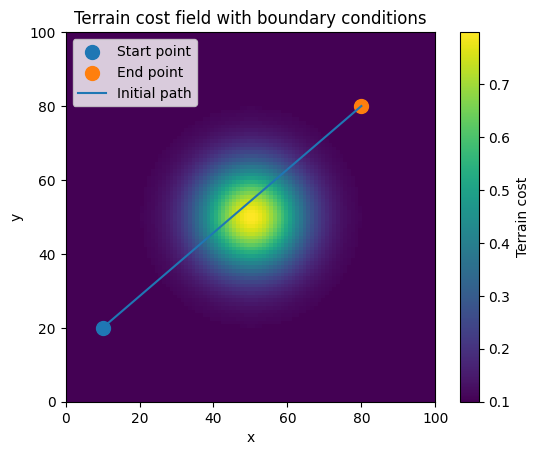

In [9]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.colorbar(label="Terrain cost")

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot(
    path_df["x"],
    path_df["y"],
    label="Initial path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

we can now check the cost of this path. here i will check that the terrain_cost function works 

In [18]:
from cost_functions.terrain_cost import terrain_cost

cost = terrain_cost(
    path,
    terrain
)

print(cost)

25.837818295842993


In [19]:
print("Straight length:", path.length())
print("Straight cost:", terrain_cost(path, terrain))

Straight length: 92.19544457292888
Straight cost: 25.837818295842993
